# Pricer de Câmbio a Termo com Cupom Cambial (USDBRL)

Este notebook demonstra como uma mesa de derivativos de câmbio no Brasil precifica um **forward de dólar (NDF)** a partir de duas curvas de juros negociadas na B3 — a curva pré-fixada (futuros de DI1) e a curva de cupom cambial (futuros de DDI) — combinadas pela **paridade coberta de juros (CIP)**.

Isso é exatamente o que uma mesa de câmbio faz para: (1) conferir se o dólar futuro (DOL) negociado em bolsa está "caro" ou "barato" frente ao que a curva de juros implica; (2) precificar um NDF para um vencimento customizado (fora dos vencimentos padronizados da bolsa); (3) medir o risco (sensibilidades) de uma posição a termo.

## Fonte dos dados

Todos os dados são **reais e públicos**, vindos diretamente da B3 e do Banco Central, via o pacote `pyield`:

- **DI1** (futuro de taxa pré) e **DDI** (futuro de cupom cambial) — dataset histórico oficial da B3 (Price Report).
- **PTAX** — câmbio de referência oficial, divulgado pelo Banco Central.

Nenhum dado é sintético. A fórmula de precificação usada aqui é a **fórmula oficial da B3**, publicada no *Manual de Curvas* (curva "Forward de Reais x Dólar", item 4.1) — validada nesta sessão contra os preços reais de ajuste do futuro DOL, com erro menor que 0,001 ponto-base em 15 vencimentos consecutivos.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Image, display

import pyield as yd
from pricer_fx_termo.dados import carregar_curvas, dias_ate_vencimento
from pricer_fx_termo.curva_pre import interpolar_pre
from pricer_fx_termo.curva_cupom import montar_curva_cupom_sujo, interpolar_cupom_sujo
from pricer_fx_termo.forward import taxa_termo
from pricer_fx_termo.ndf import taxa_par, valor_presente
from pricer_fx_termo.sensibilidades import ParametrosNDF, delta_cambial, dv01_pre, dv01_cupom

pio.templates.default = "plotly_white"

def show(fig, width=900, height=450):
    display(Image(fig.to_image(format="png", width=width, height=height, scale=2)))

DATA_REF = "31-07-2026"
DATA_ANTERIOR = "30-07-2026"

curvas = carregar_curvas(DATA_REF, DATA_ANTERIOR)
print(f"Data de referência: {DATA_REF}")
print(f"PTAX t0: {curvas.ptax_t0}  |  PTAX t-1: {curvas.ptax_t_1}  |  CDI: {curvas.cdi:.4%}")
curvas.di1.head()

Data de referência: 31-07-2026
PTAX t0: 5.0773  |  PTAX t-1: 5.0739  |  CDI: 14.1500%


,data_vencimento,dias_uteis,dias_corridos,taxa_ajuste
0,2026-08-03,1,3,0.14150
1,2026-09-01,22,32,0.13957
2,2026-10-01,43,62,0.13895
3,2026-11-03,64,95,0.13840
4,2026-12-01,83,123,0.13810


## 1. A curva pré-fixada (DI1)

A curva DI1 mostra a taxa de juros pré-fixada em reais para cada prazo (vencimento) — é a curva de referência do CDI/Selic futuro, negociada em contratos futuros de Depósito Interfinanceiro na B3. Base de contagem: dias úteis / 252, capitalização exponencial.

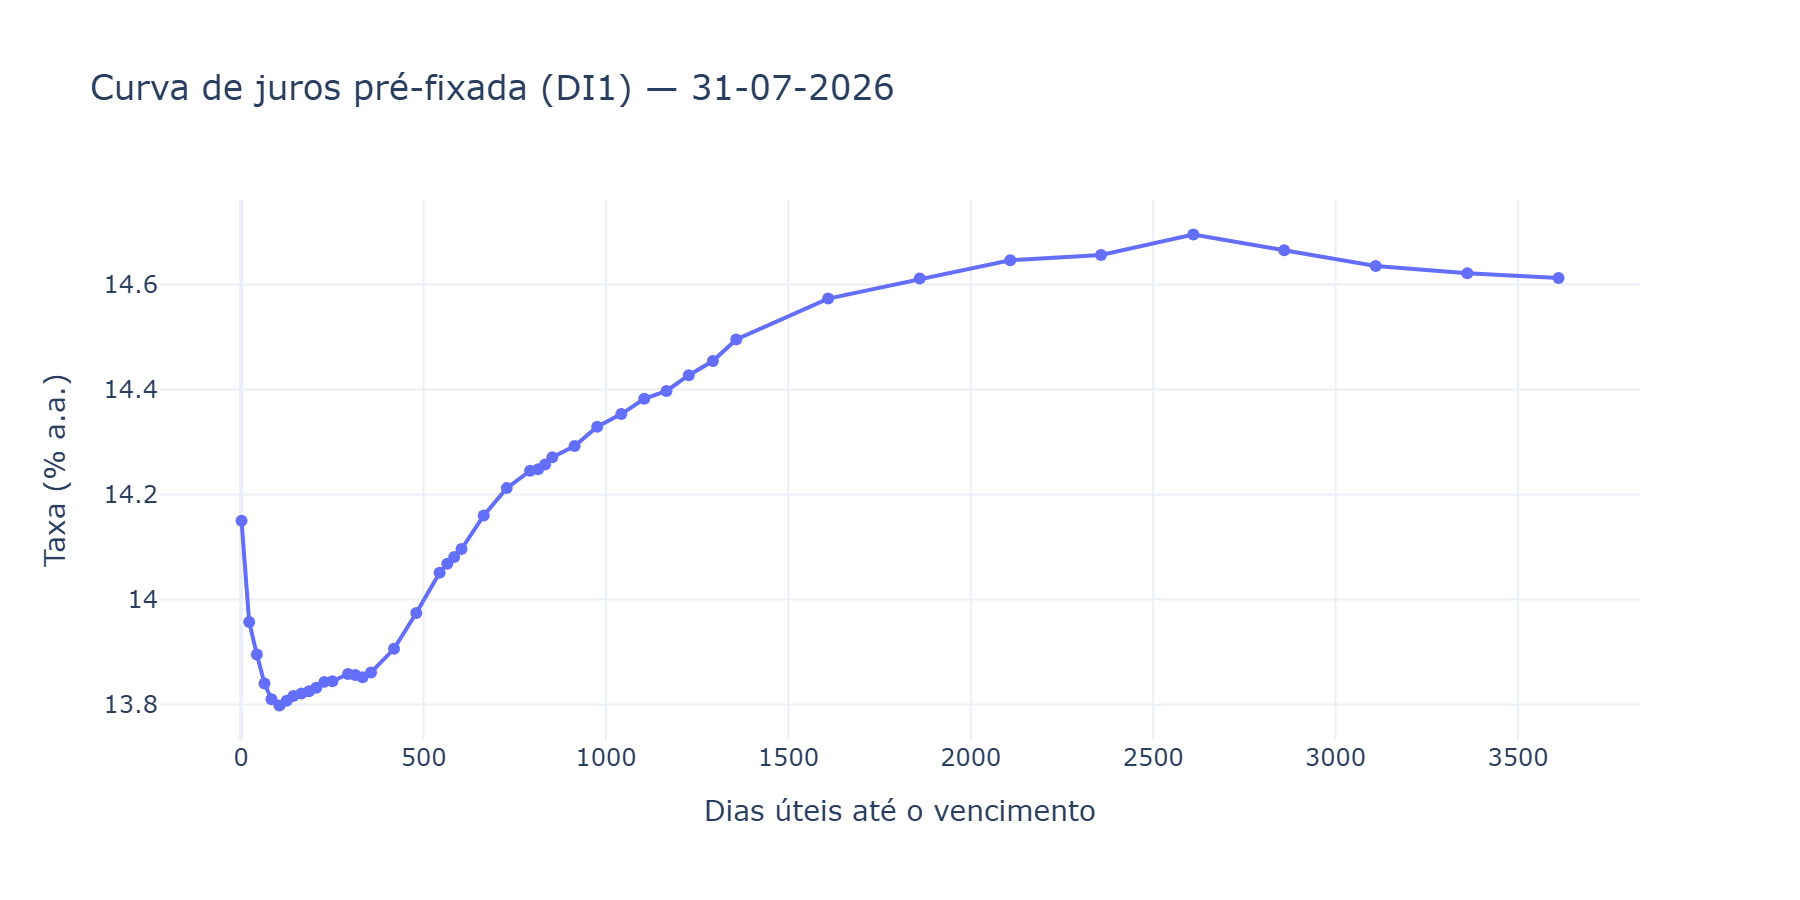

In [2]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=curvas.di1["dias_uteis"], y=curvas.di1["taxa_ajuste"]*100,
    mode="lines+markers", name="Taxa PRE (DI1)",
))
fig.update_layout(
    title=f"Curva de juros pré-fixada (DI1) — {DATA_REF}",
    xaxis_title="Dias úteis até o vencimento", yaxis_title="Taxa (% a.a.)",
)
show(fig)

## 2. A curva de cupom cambial (DDI)

O **cupom cambial** é, na prática, a taxa de juros do dólar "dentro do Brasil": o retorno implícito de manter dólares aplicados em vez de reais, dado o câmbio observado e a curva de juros local. Ele é negociado diretamente via o contrato futuro **DDI** na B3.

A curva completa de cupom cambial (chamada pela B3 de "cupom sujo") é construída em duas partes:
- **Vértice 1** (curtíssimo prazo): calculado a partir da taxa CDI do dia e da variação do PTAX entre ontem e hoje — não há contrato futuro de DDI tão curto.
- **Demais vértices**: a taxa de ajuste do próprio contrato DDI, usada diretamente, nos vencimentos em que ele é negociado.

Base de contagem: dias corridos / 360, capitalização linear (juros simples) — diferente da curva pré, que é exponencial em dias úteis/252.

In [3]:
proximo_dia_util = yd.du.deslocar(DATA_REF, 1)
du_1, dc_1 = dias_ate_vencimento(DATA_REF, str(proximo_dia_util))

curva_cupom = montar_curva_cupom_sujo(
    curvas.ddi, cdi=curvas.cdi, ptax_t0=curvas.ptax_t0, ptax_t_1=curvas.ptax_t_1,
    du_1=du_1, dc_1=dc_1,
)
curva_cupom.head()

,dias_uteis,dias_corridos,taxa
0,1,3,-0.017363
1,1,3,-0.017360
2,22,32,0.046910
3,43,62,0.048260
4,64,95,0.049360


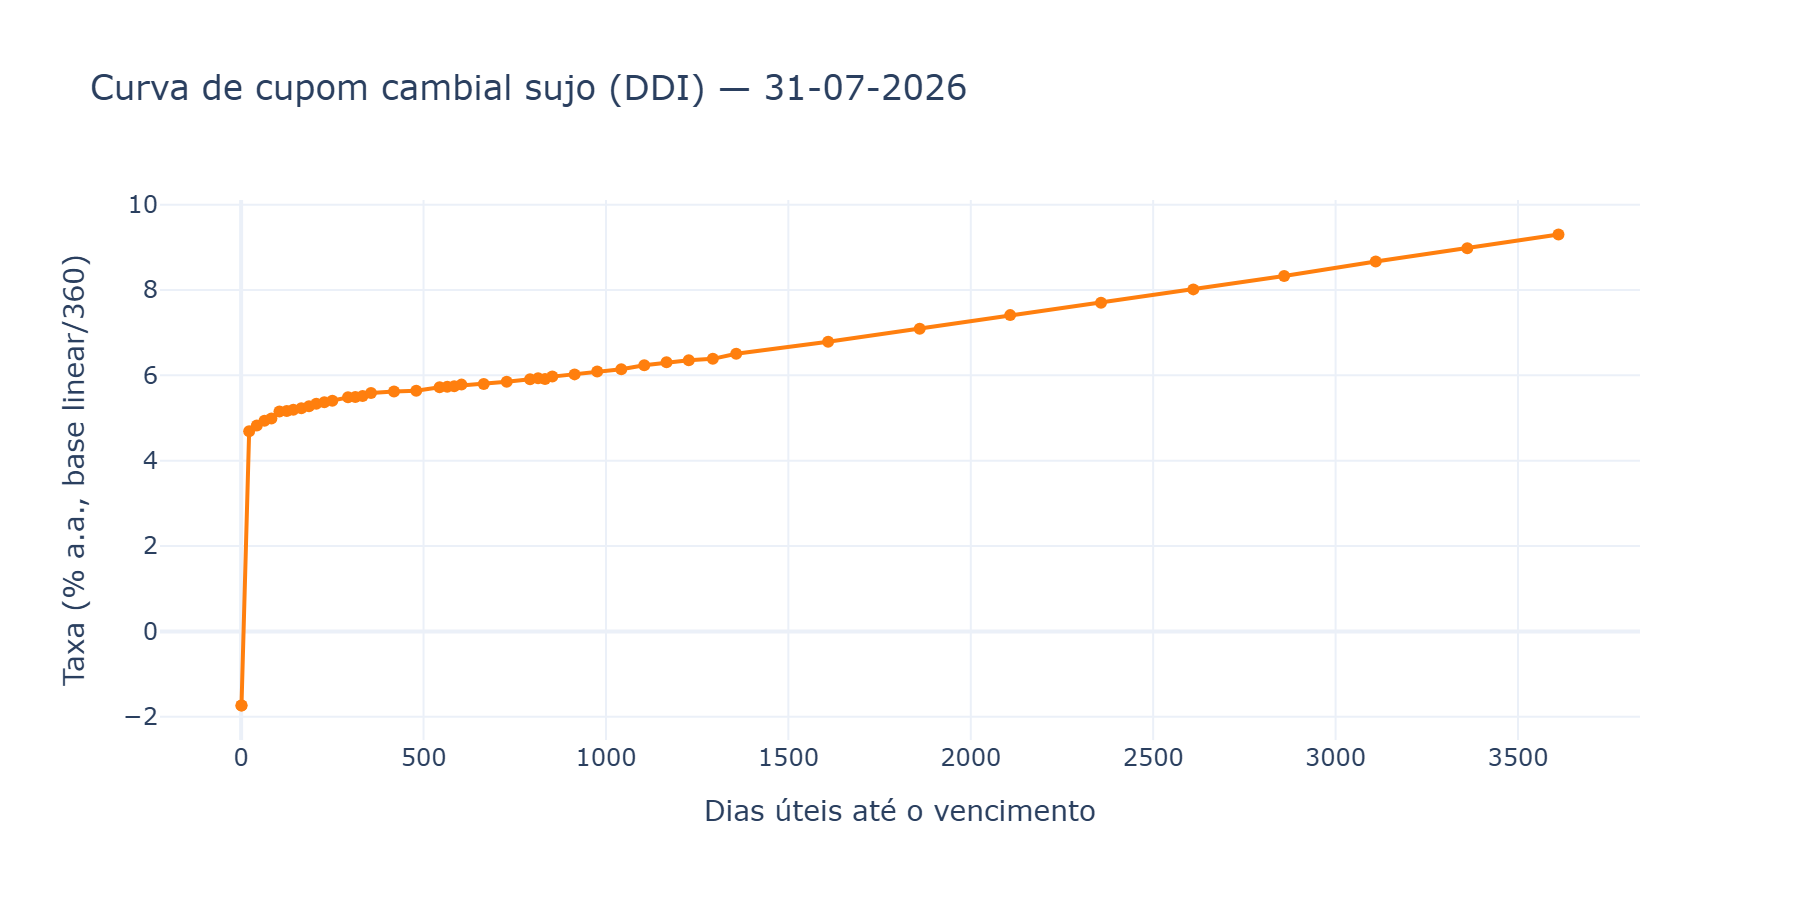

In [4]:
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=curva_cupom["dias_uteis"], y=curva_cupom["taxa"]*100,
    mode="lines+markers", name="Cupom cambial sujo (DDI)", line=dict(color="#ff7f0e"),
))
fig2.update_layout(
    title=f"Curva de cupom cambial sujo (DDI) — {DATA_REF}",
    xaxis_title="Dias úteis até o vencimento", yaxis_title="Taxa (% a.a., base linear/360)",
)
show(fig2)

## 3. Paridade coberta de juros: dólar futuro teórico x dólar futuro de mercado

Com as duas curvas em mãos, a fórmula oficial da B3 (item 4.1 do Manual de Curvas) dá o câmbio USDBRL a termo teórico para qualquer vencimento:

$$\text{termo}(n) = \frac{(1+\text{pré}_n)^{du_n/252}}{1+\text{cupom}_n \cdot dc_n/360} \times \text{PTAX}_{t-1}$$

Se o mercado for eficiente (sem fricções, arbitragem livre), esse valor teórico deve bater com o preço do futuro de dólar (DOL) realmente negociado na bolsa. Vamos comparar os dois, vencimento a vencimento.

In [5]:
dol = yd.futuro.historico(DATA_REF, "DOL").to_pandas()

comparacao = curvas.di1.merge(curvas.ddi, on="data_vencimento", suffixes=("_pre", "_cupom")) \
    .merge(dol[["data_vencimento", "preco_ajuste"]], on="data_vencimento")
comparacao["dol_mercado"] = comparacao["preco_ajuste"] / 1000
comparacao["termo_teorico"] = comparacao.apply(
    lambda r: taxa_termo(r["taxa_ajuste_pre"], r["taxa_ajuste_cupom"], r["dias_uteis_pre"], r["dias_corridos_cupom"], curvas.ptax_t_1),
    axis=1,
)
comparacao["diff_bps"] = (comparacao["termo_teorico"]/comparacao["dol_mercado"] - 1) * 10_000
comparacao[["data_vencimento", "dias_uteis_pre", "dol_mercado", "termo_teorico", "diff_bps"]]

,data_vencimento,dias_uteis_pre,dol_mercado,termo_teorico,diff_bps
0,2026-08-03,1,5.077300,5.077300,-0.000231
1,2026-09-01,22,5.110795,5.110794,-0.002856
2,2026-10-01,43,5.145041,5.145041,0.000809
3,2026-11-03,64,5.176290,5.176290,0.000387
4,2026-12-01,83,5.206048,5.206048,0.000778
5,2027-01-04,105,5.236964,5.236964,-0.000506
6,2027-02-01,125,5.270247,5.270247,0.000032
7,2027-03-01,143,5.297758,5.297758,0.000584
8,2027-04-01,165,5.333633,5.333633,0.000344
9,2027-05-03,186,5.365741,5.365741,0.000226


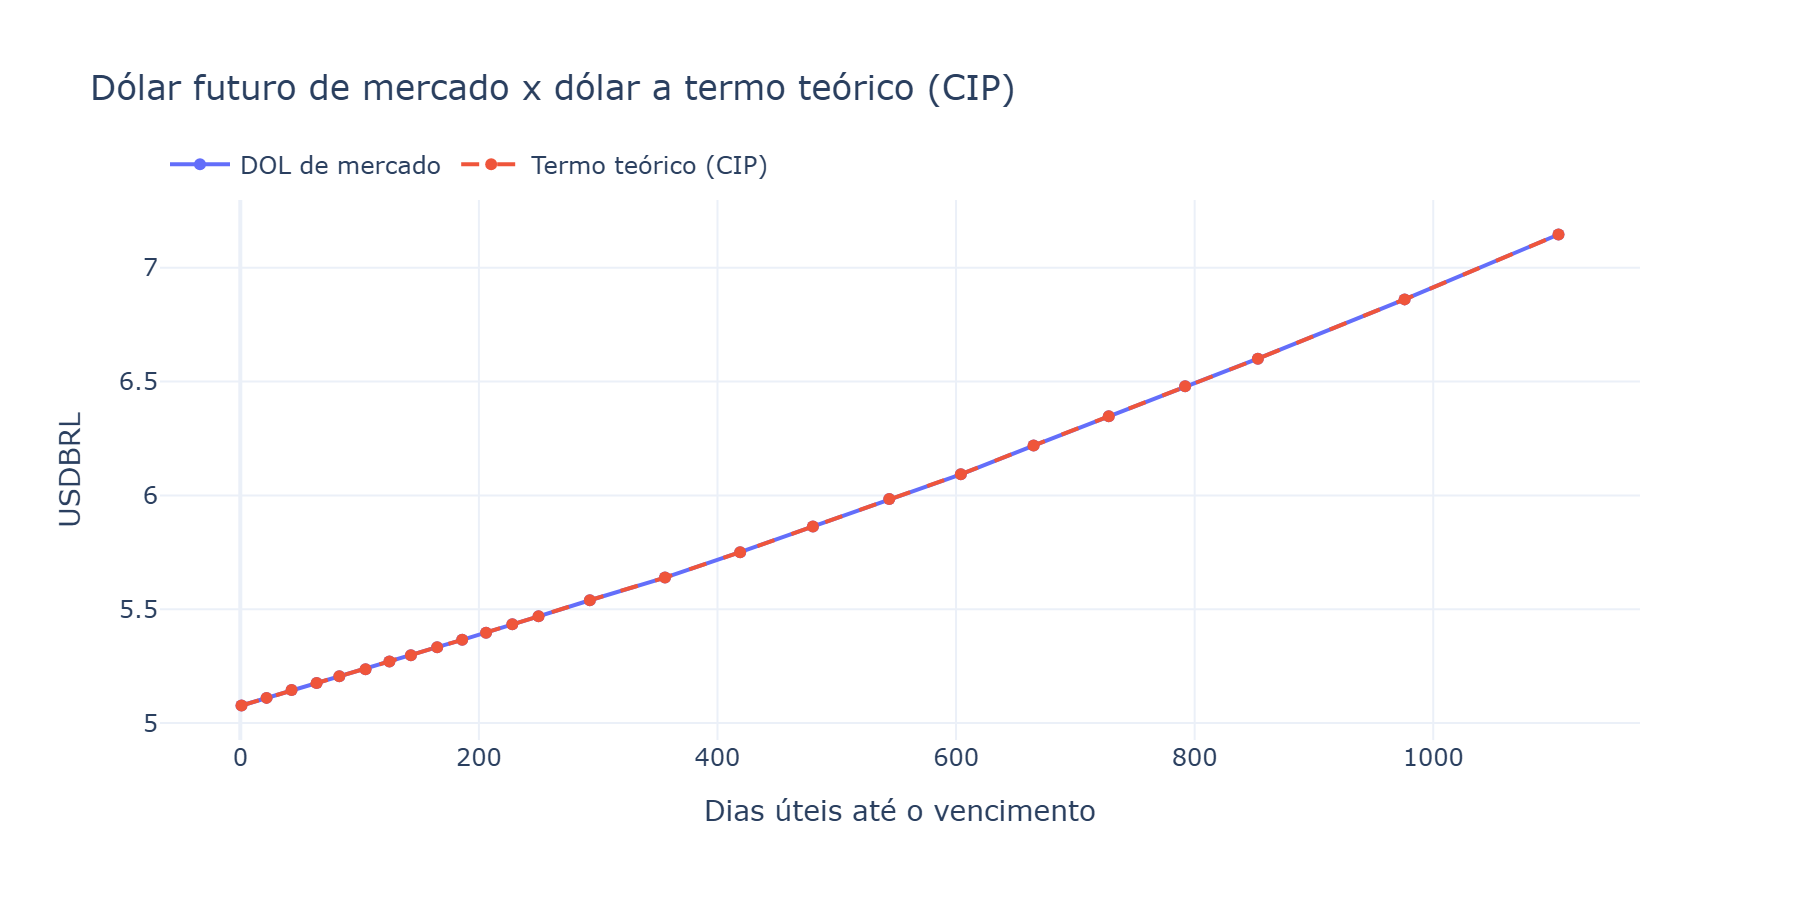

Diferença máxima observada (bps): 0.0028556252251732417


In [6]:
fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=comparacao["dias_uteis_pre"], y=comparacao["dol_mercado"], name="DOL de mercado", mode="lines+markers"))
fig3.add_trace(go.Scatter(x=comparacao["dias_uteis_pre"], y=comparacao["termo_teorico"], name="Termo teórico (CIP)", mode="lines+markers", line=dict(dash="dash")))
fig3.update_layout(
    title="Dólar futuro de mercado x dólar a termo teórico (CIP)",
    xaxis_title="Dias úteis até o vencimento", yaxis_title="USDBRL",
    legend=dict(orientation="h", y=1.12),
)
show(fig3)

print("Diferença máxima observada (bps):", comparacao["diff_bps"].abs().max())

**Leitura de negócio:** as duas curvas praticamente se sobrepõem — a diferença residual (poucos milésimos de ponto-base) é ruído de arredondamento, não uma oportunidade de arbitragem real. Isso confirma que o dólar futuro negociado na B3 respeita a paridade coberta de juros com a curva de cupom cambial, como esperado em um mercado líquido e arbitrado.

## 4. Precificando um NDF customizado

Uma mesa de câmbio frequentemente precisa de uma taxa a termo para um vencimento que **não** coincide com nenhum vencimento padronizado de DI1/DDI (ex.: um NDF sob medida para o fluxo de caixa de um cliente). Para isso, interpolamos as duas curvas no prazo desejado e aplicamos a mesma fórmula de paridade coberta de juros.

Exemplo: um NDF comprado em USD 5.000.000, vencimento em 6 meses, taxa contratada de R$ 5,50/US$.

In [7]:
vencimento_ndf = (pd.to_datetime(DATA_REF, dayfirst=True) + pd.DateOffset(months=6)).strftime("%d-%m-%Y")
du_ndf, dc_ndf = dias_ate_vencimento(DATA_REF, vencimento_ndf)
print(f"Vencimento do NDF: {vencimento_ndf}  ({du_ndf} dias úteis, {dc_ndf} dias corridos)")

pre_ndf = interpolar_pre(curvas.di1, du_ndf)
cupom_ndf = interpolar_cupom_sujo(curva_cupom, du_ndf, dc_ndf)
termo_ndf = taxa_termo(pre_ndf, cupom_ndf, du_ndf, dc_ndf, curvas.ptax_t_1)

print(f"Taxa pré interpolada: {pre_ndf:.4%}")
print(f"Cupom cambial interpolado: {cupom_ndf:.4%}")
print(f"Câmbio a termo teórico (taxa 'par' do NDF): {termo_ndf:.4f}")

Vencimento do NDF: 31-01-2027  (125 dias úteis, 184 dias corridos)
Taxa pré interpolada: 13.8070%
Cupom cambial interpolado: 5.1630%
Câmbio a termo teórico (taxa 'par' do NDF): 5.2710


In [8]:
NOTIONAL_USD = 5_000_000.0
TAXA_CONTRATADA = 5.50

valor_ndf = valor_presente(
    notional_usd=NOTIONAL_USD, taxa_contratada=TAXA_CONTRATADA,
    taxa_termo_teorica=termo_ndf, pre_liquidacao=pre_ndf, du_liquidacao=du_ndf,
)
print(f"Taxa contratada: R$ {TAXA_CONTRATADA:.4f}/US$")
print(f"Taxa a termo teórica (par): R$ {termo_ndf:.4f}/US$")
print(f"Valor presente do NDF: R$ {valor_ndf:,.2f}")

Taxa contratada: R$ 5.5000/US$
Taxa a termo teórica (par): R$ 5.2710/US$
Valor presente do NDF: R$ -1,073,928.39


**Leitura de negócio:** como a taxa contratada (R$ 5,50) é diferente da taxa a termo teórica de mercado, o NDF já nasce com valor de marcação a mercado diferente de zero — positivo para quem comprou USD a termo, se a taxa teórica implícita no mercado está acima da taxa contratada.

## 5. Sensibilidades (risco) do NDF

Em vez de derivar fórmulas fechadas para cada "grego", cada sensibilidade abaixo choca um insumo da curva (câmbio, taxa pré ou cupom cambial) para cima e para baixo em uma quantidade pequena e reprecifica o NDF nos dois cenários — a mesma técnica ("bump-and-reprice") usada em mesas de risco reais.

In [9]:
params = ParametrosNDF(
    notional_usd=NOTIONAL_USD, taxa_contratada=TAXA_CONTRATADA,
    pre_n=pre_ndf, cd_n=cupom_ndf, du_n=du_ndf, dc_n=dc_ndf,
    ptax_t_1=curvas.ptax_t_1, pre_liquidacao=pre_ndf, du_liquidacao=du_ndf,
)

delta = delta_cambial(params)
dv01_p = dv01_pre(params)
dv01_c = dv01_cupom(params)

print(f"Delta cambial (choque de 1% no câmbio): R$ {delta:,.2f}")
print(f"DV01 pré (choque de 1bp na taxa pré):    R$ {dv01_p:,.2f}")
print(f"DV01 cupom (choque de 1bp no cupom):     R$ {dv01_c:,.2f}")

Delta cambial (choque de 1% no câmbio): R$ 247,172.45
DV01 pré (choque de 1bp na taxa pré):    R$ 1,124.12
DV01 cupom (choque de 1bp no cupom):     R$ -1,230.85


**Nota sobre unidades:** delta cambial e DV01 respondem a choques de tamanhos diferentes (1% de câmbio vs. 1 ponto-base de taxa) e não são diretamente comparáveis em um único gráfico de barras — é por isso que, abaixo, o delta cambial é reportado isoladamente e o DV01 pré x DV01 cupom (esses sim na mesma unidade de choque) são comparados entre si.

In [10]:
print(f"Delta cambial: para cada 1% de valorização do dólar, o NDF ganha/perde R$ {delta:,.2f}")

Delta cambial: para cada 1% de valorização do dólar, o NDF ganha/perde R$ 247,172.45


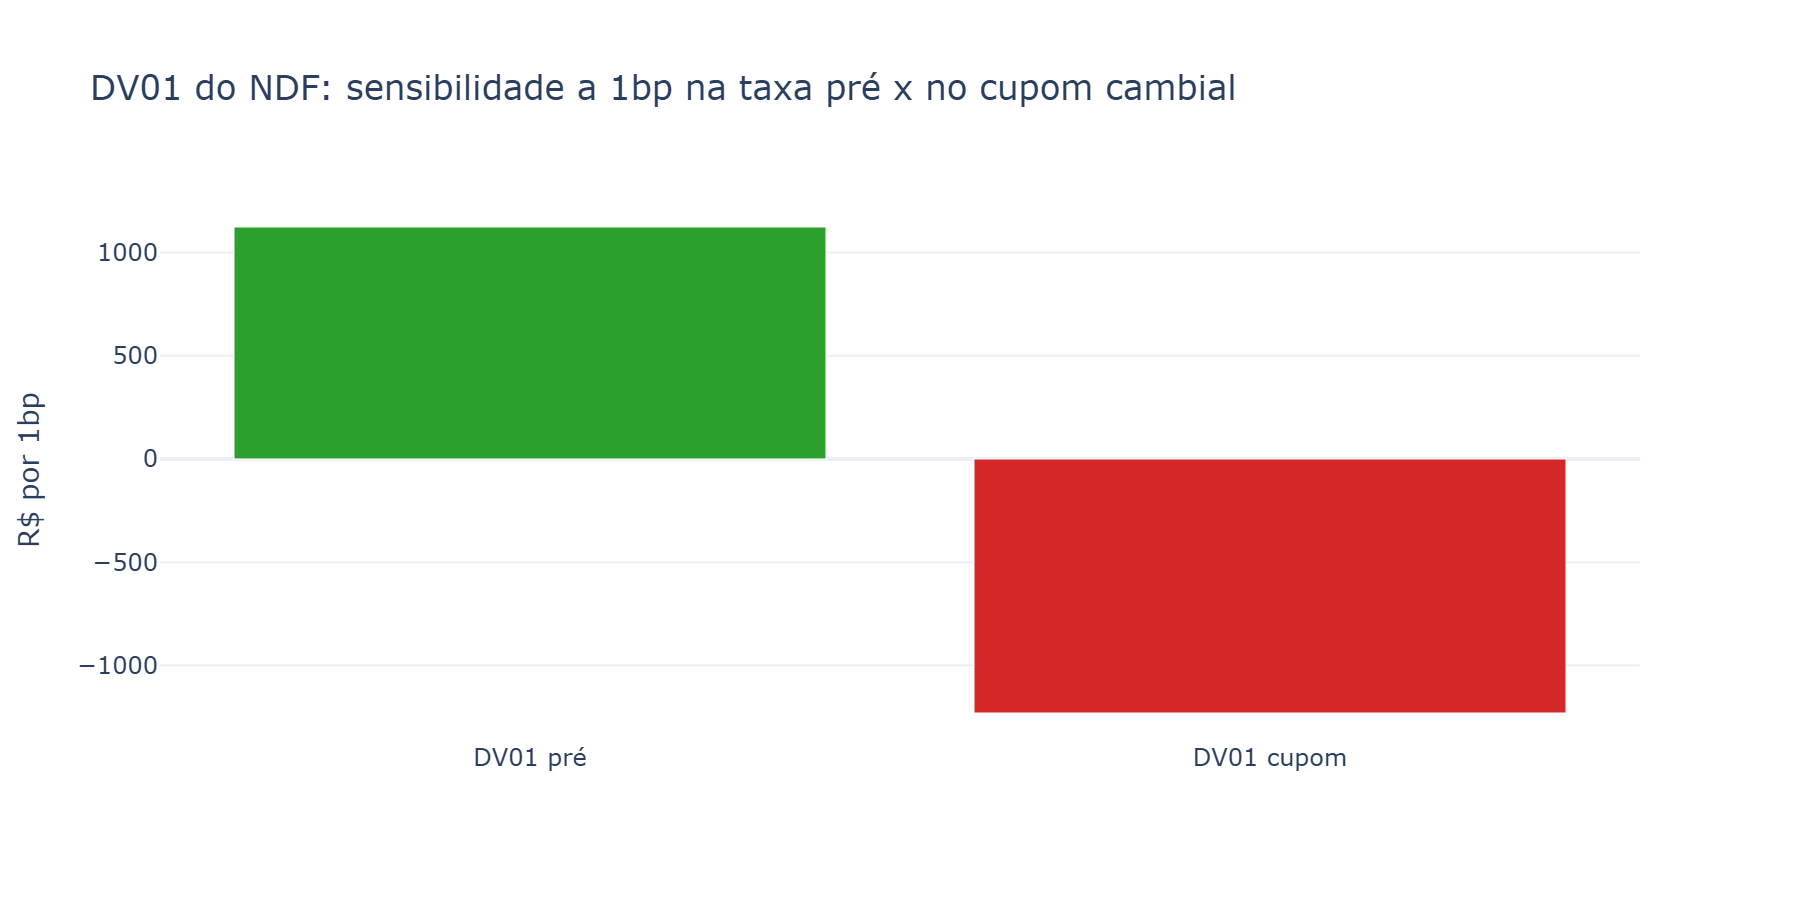

In [11]:
fig4 = go.Figure()
fig4.add_trace(go.Bar(
    x=["DV01 pré", "DV01 cupom"],
    y=[dv01_p, dv01_c],
    marker_color=["#2ca02c", "#d62728"],
))
fig4.update_layout(
    title="DV01 do NDF: sensibilidade a 1bp na taxa pré x no cupom cambial",
    yaxis_title="R$ por 1bp",
)
show(fig4)

**Leitura de negócio:** o delta cambial domina o risco total do NDF (esperado — é um NDF de câmbio de USD 5 milhões, e 1% de câmbio é uma variação bem maior que 1bp de taxa de juros). O DV01 pré é positivo: para este prazo, o efeito de uma taxa pré mais alta sobre a taxa a termo teórica supera o efeito sobre o fator de desconto do payoff. O DV01 cupom é negativo por construção: cupom cambial mais alto reduz o câmbio a termo teórico (ele entra no denominador da fórmula de paridade), o que reduz o valor de uma posição comprada em dólar a termo.

## Conclusão

Este notebook implementou, do zero, a metodologia oficial da B3 para a curva de câmbio a termo (item 4.1 do *Manual de Curvas*), validada contra os preços reais do futuro de dólar (DOL) com erro inferior a 0,01 ponto-base. A partir dela, precificamos um NDF customizado e medimos seu perfil de risco via bump-and-reprice.

**Limitações conhecidas:**
- A curva de cupom cambial usa apenas os vencimentos "padronizados" de DDI; a B3 também usa contratos FRC (forward de cupom) para alguns vértices — não incorporados nesta v1.
- A interpolação para vencimentos entre vértices (item 1.4.3 do manual) foi reconstruída por analogia estrutural com a interpolação exponencial (1.4.2, essa sim reproduzida literalmente do manual) — o mecanismo central de precificação (fórmula de paridade coberta de juros, item 4.1) foi validado numericamente contra 15 preços reais de mercado; a fórmula de interpolação entre vértices tem o mesmo nível de rigor estrutural, mas não foi validada ponto a ponto contra uma curva oficial de cupom limpo publicada pela B3.